## 1. Import Required Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add rosbag_loader to path
sys.path.insert(0, str(Path.cwd().parent))

from rosbag_loader import inspect_bag_topics, load_bag_topics, BagData

sns.set_style('darkgrid')
%matplotlib inline

## 2. Set Bag Path and Inspect Topics

In [2]:
# Use the first available bag
bag_path = 'C:\\Users\\luchs\\MyData\\Education\\Master_TUM\\25WS\\Guided Research\\radar-iwr6843-driver\\rosbags\\backflips_2025-12-17-17-41-24.bag'

# Inspect bag topics
topics_info = inspect_bag_topics(bag_path)


Bag inspection: C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\backflips_2025-12-17-17-41-24.bag
Duration: 55.57 seconds

Topic                                              Type                                        Count
----------------------------------------------------------------------------------------------------
/angrybird2/active_reference/markers               visualization_msgs/Marker                   16782
/angrybird2/active_reference/path                  nav_msgs/Path                               16615
/angrybird2/agiros_pilot/enable                    std_msgs/Bool                                   2
/angrybird2/agiros_pilot/go_to_pose                geometry_msgs/PoseStamped                       1
/angrybird2/agiros_pilot/land                      std_msgs/Empty                                  1
/angrybird2/agiros_pilot/mpc_command               agiros_msgs/Command                         16719
/angrybird2/agiros_pilo

## 3. Load Rosbag Topics into Data Structures

In [3]:
# Load all topics
bag_data = load_bag_topics(bag_path, verbose=True)

# Display summary
print("\nData Summary:")
for key, value in bag_data.summary().items():
    print(f"  {key}: {value}")


Loading rosbag: backflips_2025-12-17-17-41-24.bag
Duration: 55.57s
  Loading /mocap/angrybird2/pose...
  Loading /mocap/angrybird2/accel...
  Loading /angrybird2/agiros_pilot/state...
  Loading /angrybird2/agiros_pilot/odometry...
  Loading /angrybird2/imu...
  Loading /ti_mmwave/radar_scan_pcl_0...
  Loading /mmWaveDataHdl/RScanVelocity...
  Done!


Data Summary:
  bag_path: C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\backflips_2025-12-17-17-41-24.bag
  duration_s: 55.569387912750244
  mocap_pose_samples: 5557
  mocap_accel_samples: 5599
  agiros_state_samples: 16753
  agiros_odometry_samples: 16741
  imu_samples: 55210
  radar_pcl_samples: 984
  radar_velocity_samples: 984


## 4. Examine Loaded Data

In [4]:
# MoCap Pose Data
if bag_data.mocap_pose:
    print("\nMoCap Pose (first 3 samples):")
    for pose in bag_data.mocap_pose[:3]:
        print(f"  t={pose.timestamp:.3f}: pos={pose.position}")
else:
    print("No MoCap Pose data found")


MoCap Pose (first 3 samples):
  t=1765989685.865: pos=[-1.81258049  1.53468549  0.11871355]
  t=1765989685.874: pos=[-1.81257091  1.53468838  0.11869739]
  t=1765989685.881: pos=[-1.81258116  1.53468557  0.11871541]


In [5]:
# Agiros State Data
if bag_data.agiros_state:
    print("\nAgiros State (first 3 samples):")
    for state in bag_data.agiros_state[:3]:
        print(f"  t={state.timestamp:.3f}: pos={state.position}, vel={state.velocity}")
else:
    print("No Agiros State data found")


Agiros State (first 3 samples):
  t=1765989685.864: pos=[-1.8126486   1.53461725  0.11865908], vel=[ 9.94581684e-05  9.99993604e-05 -1.10455816e-05]
  t=1765989685.864: pos=[-1.81264826  1.5346176   0.11865906], vel=[ 1.04974241e-04  1.07951309e-04 -5.82212245e-06]
  t=1765989685.864: pos=[-1.81264791  1.53461795  0.11865904], vel=[ 1.10245933e-04  1.15550959e-04 -8.30080021e-07]


In [6]:
# IMU Data
if bag_data.imu_data:
    print("\nIMU Data (first 3 samples):")
    for imu in bag_data.imu_data[:3]:
        print(f"  t={imu.timestamp:.3f}: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
else:
    print("No IMU data found")


IMU Data (first 3 samples):
  t=1765989685.865: accel=[ 0.      -2.0601   9.73152], gyro=[-0.036 -0.063  0.153]
  t=1765989685.865: accel=[ 0.      -2.0601   9.73152], gyro=[-0.033 -0.063  0.152]
  t=1765989685.866: accel=[ 0.      -2.0601   9.73152], gyro=[-0.031 -0.062  0.152]


In [7]:
# Radar Data
if bag_data.radar_pcl:
    print("\nRadar Point Cloud (first 3 samples):")
    for pcl in bag_data.radar_pcl[:3]:
        print(f"  t={pcl.timestamp:.3f}: {pcl.num_points()} points")
else:
    print("No Radar Point Cloud data found")


Radar Point Cloud (first 3 samples):
  t=1765989692.451: 1 points
  t=1765989692.684: 1 points
  t=1765989692.784: 1 points


## 5. Convert to DataFrames for Analysis

In [8]:
# Convert MoCap Pose to DataFrame
if bag_data.mocap_pose:
    mocap_pose_df = pd.DataFrame([pose.to_dict() for pose in bag_data.mocap_pose])
    print("MoCap Pose DataFrame:")
    print(mocap_pose_df.head())
    print(f"Shape: {mocap_pose_df.shape}")

MoCap Pose DataFrame:
      timestamp         x         y         z        qx        qy        qz  \
0  1.765990e+09 -1.812580  1.534685  0.118714 -0.092522 -0.011420  0.186504   
1  1.765990e+09 -1.812571  1.534688  0.118697 -0.092469 -0.011522  0.186508   
2  1.765990e+09 -1.812581  1.534686  0.118715 -0.092489 -0.011434  0.186502   
3  1.765990e+09 -1.812556  1.534663  0.118683 -0.092472 -0.011558  0.186558   
4  1.765990e+09 -1.812641  1.534599  0.118650 -0.092309 -0.011428  0.186247   

         qw  
0  0.978021  
1  0.978024  
2  0.978025  
3  0.978014  
4  0.978090  
Shape: (5557, 8)


In [9]:
# Convert Agiros State to DataFrame
if bag_data.agiros_state:
    agiros_state_df = pd.DataFrame([state.to_dict() for state in bag_data.agiros_state])
    print("Agiros State DataFrame:")
    print(agiros_state_df.head())
    print(f"Shape: {agiros_state_df.shape}")

Agiros State DataFrame:
      timestamp         x         y         z        vx        vy  \
0  1.765990e+09 -1.812649  1.534617  0.118659  0.000099  0.000100   
1  1.765990e+09 -1.812648  1.534618  0.118659  0.000105  0.000108   
2  1.765990e+09 -1.812648  1.534618  0.118659  0.000110  0.000116   
3  1.765990e+09 -1.812644  1.534616  0.118652  0.000233  0.000038   
4  1.765990e+09 -1.812644  1.534616  0.118651  0.000241  0.000044   

             vz        qx        qy        qz  ...        wx        wy  \
0 -1.104558e-05 -0.092299 -0.011461  0.186254  ... -0.005600 -0.007782   
1 -5.822122e-06 -0.092306 -0.011476  0.186250  ... -0.005600 -0.007782   
2 -8.300800e-07 -0.092312 -0.011491  0.186246  ... -0.005600 -0.007782   
3 -2.606328e-04 -0.092281 -0.011466  0.186265  ...  0.000266 -0.003831   
4 -2.622489e-04 -0.092280 -0.011472  0.186266  ...  0.000266 -0.003831   

         wz        ax        ay        az  motor1  motor2  motor3  motor4  
0 -0.002943  0.001651  0.002379  0.00156

In [10]:
# Convert IMU to DataFrame
if bag_data.imu_data:
    imu_df = pd.DataFrame([imu.to_dict() for imu in bag_data.imu_data])
    print("IMU DataFrame:")
    print(imu_df.head())
    print(f"Shape: {imu_df.shape}")

IMU DataFrame:
      timestamp   ax      ay       az     wx     wy     wz
0  1.765990e+09  0.0 -2.0601  9.73152 -0.036 -0.063  0.153
1  1.765990e+09  0.0 -2.0601  9.73152 -0.033 -0.063  0.152
2  1.765990e+09  0.0 -2.0601  9.73152 -0.031 -0.062  0.152
3  1.765990e+09  0.0 -2.0601  9.72171 -0.031 -0.062  0.152
4  1.765990e+09  0.0 -2.0601  9.72171 -0.033 -0.061  0.152
Shape: (55210, 7)


## 6. Visualization: Trajectory Comparison

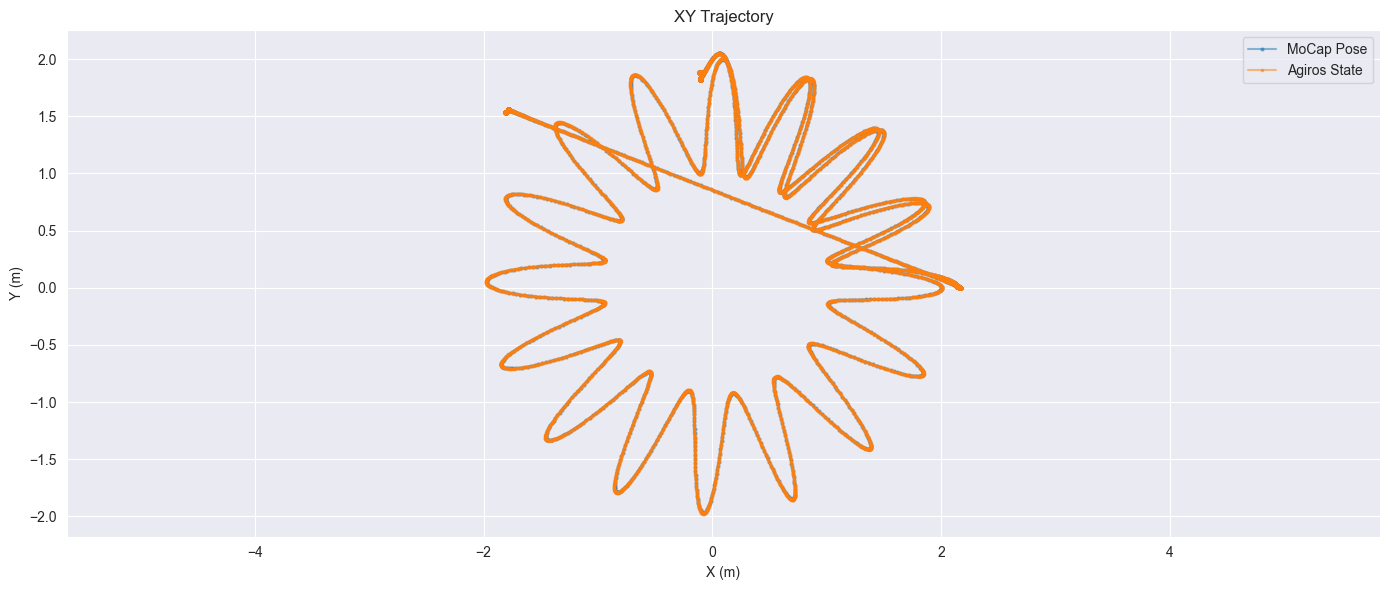

In [11]:
# Plot trajectories from different sensors
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# XY trajectory
if bag_data.mocap_pose and mocap_pose_df is not None:
    ax.plot(mocap_pose_df['x'], mocap_pose_df['y'], 'o-', alpha=0.5, label='MoCap Pose', markersize=2)

if bag_data.agiros_state and agiros_state_df is not None:
    ax.plot(agiros_state_df['x'], agiros_state_df['y'], 's-', alpha=0.5, label='Agiros State', markersize=2)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('XY Trajectory')
ax.legend()
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()


In [15]:
imu_df

,timestamp,ax,ay,az,wx,wy,wz
0,1.765990e+09,0.00000,-2.06010,9.73152,-0.036,-0.063,0.153
1,1.765990e+09,0.00000,-2.06010,9.73152,-0.033,-0.063,0.152
2,1.765990e+09,0.00000,-2.06010,9.73152,-0.031,-0.062,0.152
3,1.765990e+09,0.00000,-2.06010,9.72171,-0.031,-0.062,0.152
4,1.765990e+09,0.00000,-2.06010,9.72171,-0.033,-0.061,0.152
...,...,...,...,...,...,...,...
55205,1.765990e+09,-2.90376,-0.08829,9.12330,-0.032,-0.062,0.153
55206,1.765990e+09,-2.90376,-0.08829,9.12330,-0.032,-0.063,0.150
55207,1.765990e+09,-2.90376,-0.07848,9.12330,-0.032,-0.062,0.149
55208,1.765990e+09,-2.90376,-0.07848,9.12330,-0.030,-0.062,0.147


## 7. Visualization: IMU Acceleration

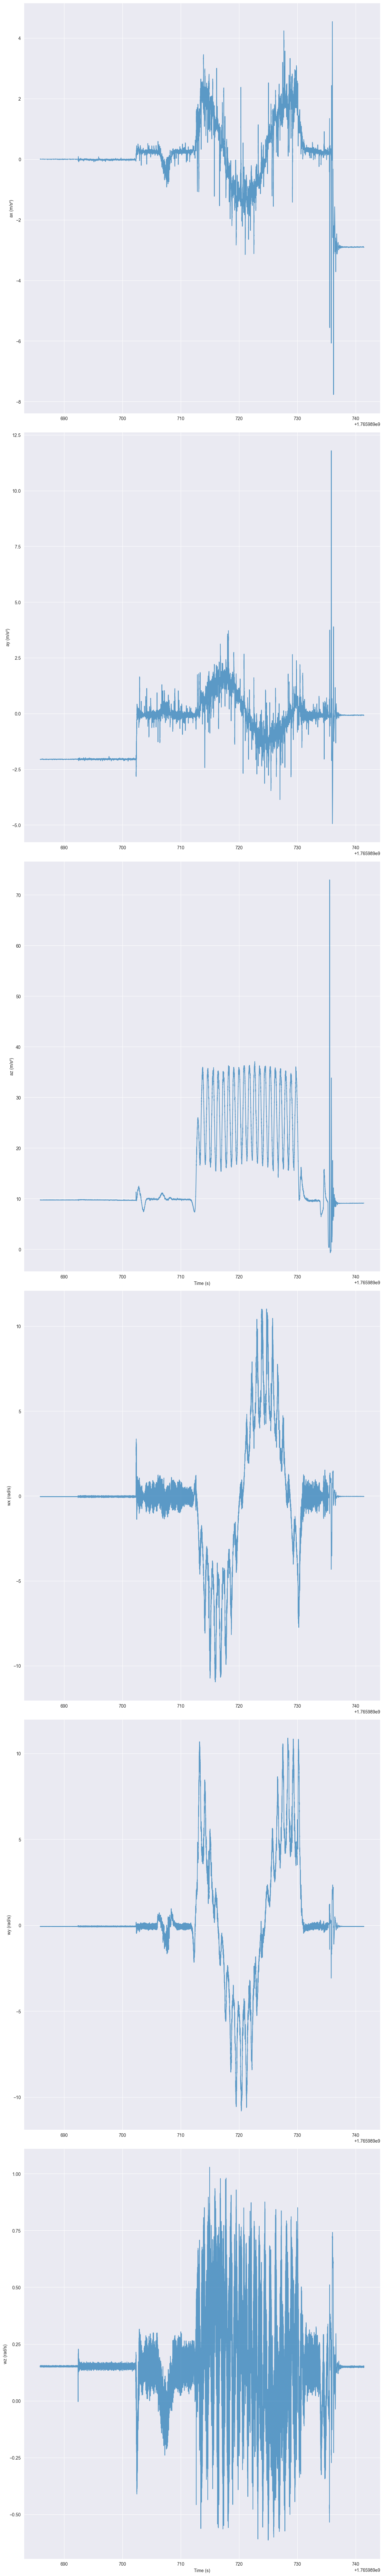

In [18]:
# Plot IMU acceleration
if bag_data.imu_data and imu_df is not None:
    fig, axes = plt.subplots(6, 1, figsize=(12, 80))
    
    axes[0].plot(imu_df['timestamp'], imu_df['ax'], alpha=0.7)
    axes[0].set_ylabel('ax (m/s²)')
    axes[0].grid(True)
    
    axes[1].plot(imu_df['timestamp'], imu_df['ay'], alpha=0.7)
    axes[1].set_ylabel('ay (m/s²)')
    axes[1].grid(True)
    
    axes[2].plot(imu_df['timestamp'], imu_df['az'], alpha=0.7)
    axes[2].set_ylabel('az (m/s²)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True)
    
    axes[3].plot(imu_df['timestamp'], imu_df['wx'], alpha=0.7)
    axes[3].set_ylabel('wx (rad/s)')
    axes[3].grid(True)
    
    axes[4].plot(imu_df['timestamp'], imu_df['wy'], alpha=0.7)
    axes[4].set_ylabel('wy (rad/s)')
    axes[4].grid(True)
    
    axes[5].plot(imu_df['timestamp'], imu_df['wz'], alpha=0.7)
    axes[5].set_ylabel('wz (rad/s)')
    axes[5].set_xlabel('Time (s)')
    axes[5].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("No IMU data to plot")

## 8. Synchronization Analysis

Find time bounds where all available sensors have data for synchronized processing.

In [13]:
# Get synchronized time bounds
t_min, t_max = bag_data.get_sync_time_bounds()

print(f"\nSynchronization Analysis:")
print(f"  Sync time range: {t_min:.3f} to {t_max:.3f}")
print(f"  Sync duration: {t_max - t_min:.3f} seconds")
print(f"\n  Individual sensor time ranges:")

if bag_data.mocap_pose:
    dt = bag_data.mocap_pose[-1].timestamp - bag_data.mocap_pose[0].timestamp
    print(f"    MoCap Pose: {bag_data.mocap_pose[0].timestamp:.3f} - {bag_data.mocap_pose[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.agiros_state:
    dt = bag_data.agiros_state[-1].timestamp - bag_data.agiros_state[0].timestamp
    print(f"    Agiros State: {bag_data.agiros_state[0].timestamp:.3f} - {bag_data.agiros_state[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.imu_data:
    dt = bag_data.imu_data[-1].timestamp - bag_data.imu_data[0].timestamp
    print(f"    IMU: {bag_data.imu_data[0].timestamp:.3f} - {bag_data.imu_data[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.radar_pcl:
    dt = bag_data.radar_pcl[-1].timestamp - bag_data.radar_pcl[0].timestamp
    print(f"    Radar PCL: {bag_data.radar_pcl[0].timestamp:.3f} - {bag_data.radar_pcl[-1].timestamp:.3f} ({dt:.3f}s)")


Synchronization Analysis:
  Sync time range: 1765989692.451 to 1765989737.085
  Sync duration: 44.635 seconds

  Individual sensor time ranges:
    MoCap Pose: 1765989685.865 - 1765989741.425 (55.560s)
    Agiros State: 1765989685.864 - 1765989741.430 (55.566s)
    IMU: 1765989685.865 - 1765989741.432 (55.567s)
    Radar PCL: 1765989692.451 - 1765989737.085 (44.635s)


## 9. Usage for Factor Graph Pipeline

Example of how to access data for factor graph construction:

In [14]:
# Example: Iterate through synchronized data for factor graph
print("\nExample: Iterating through synchronized data for factor graph construction")
print("="*60)

t_min, t_max = bag_data.get_sync_time_bounds()

# Create index mapping for synchronized data
sync_mocap_idx = [i for i, pose in enumerate(bag_data.mocap_pose) 
                  if t_min <= pose.timestamp <= t_max]
sync_imu_idx = [i for i, imu in enumerate(bag_data.imu_data) 
                if t_min <= imu.timestamp <= t_max]

print(f"\nSynchronized data indices:")
print(f"  MoCap Pose: {len(sync_mocap_idx)} samples")
print(f"  IMU: {len(sync_imu_idx)} samples")

# Example: Get first synchronized pose and IMU measurement
if sync_mocap_idx and sync_imu_idx:
    pose = bag_data.mocap_pose[sync_mocap_idx[0]]
    imu = bag_data.imu_data[sync_imu_idx[0]]
    
    print(f"\nFirst synchronized measurements:")
    print(f"  MoCap Pose: pos={pose.position}, ori={pose.orientation}")
    print(f"  IMU: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
    print(f"  Time diff: {abs(pose.timestamp - imu.timestamp):.6f} seconds")


Example: Iterating through synchronized data for factor graph construction

Synchronized data indices:
  MoCap Pose: 4464 samples
  IMU: 44326 samples

First synchronized measurements:
  MoCap Pose: pos=[-1.81236487  1.53504148  0.11888947], ori=[-0.09226606 -0.01108531  0.18565864  0.97821008]
  IMU: accel=[-0.00981 -2.06991  9.65304], gyro=[-0.025 -0.038  0.164]
  Time diff: 0.001777 seconds
